<a href="https://colab.research.google.com/github/suhanisatpude/-IMDB-Review-Analyzer/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import nltk
import re
import string
text = "The Sun is the star located at the centre of the Solar System. It is a massive sphere of hot plasma, heated to incandescence by nuclear fusion reactions in its core, radiating the energy from its surface mainly as visible light and infrared radiation with 10% at ultraviolet[18][19][20][21] energies.It is the main source of energy for life on Earth. The Sun has been an object of veneration in many cultures and a central subject of astronomical research since antiquity."

In [4]:
text = text.lower()

In [5]:
text = re.sub(r'[^a-zA-Z\s]', '', text)

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Ensure necessary NLTK data is downloaded
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added to resolve the LookupError

# Tokenize the text into words
words = word_tokenize(text)

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Filter out stopwords and non-alphabetic tokens
filtered_words = [word for word in words if word.lower() not in stop_words and word.isalpha()]

print('Words after tokenization and stopword removal:')
print(filtered_words)

Words after tokenization and stopword removal:
['sun', 'star', 'located', 'centre', 'solar', 'system', 'massive', 'sphere', 'hot', 'plasma', 'heated', 'incandescence', 'nuclear', 'fusion', 'reactions', 'core', 'radiating', 'energy', 'surface', 'mainly', 'visible', 'light', 'infrared', 'radiation', 'ultraviolet', 'energiesit', 'main', 'source', 'energy', 'life', 'earth', 'sun', 'object', 'veneration', 'many', 'cultures', 'central', 'subject', 'astronomical', 'research', 'since', 'antiquity']


In [7]:
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data for lemmatization
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [8]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]
text_lemmatized = ' '.join(lemmatized_words)

print('\nText after lemmatization:') # Fixed SyntaxError by escaping the newline
print(text_lemmatized)


Text after lemmatization:
sun star located centre solar system massive sphere hot plasma heated incandescence nuclear fusion reaction core radiating energy surface mainly visible light infrared radiation ultraviolet energiesit main source energy life earth sun object veneration many culture central subject astronomical research since antiquity


In [9]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in filtered_words]
text_stemmed = ' '.join(stemmed_words)

print('\nText after stemming:')
print(text_stemmed)


Text after stemming:
sun star locat centr solar system massiv sphere hot plasma heat incandesc nuclear fusion reaction core radiat energi surfac mainli visibl light infrar radiat ultraviolet energiesit main sourc energi life earth sun object vener mani cultur central subject astronom research sinc antiqu


In [10]:
import pandas as pd
tex = pd.read_csv('/content/IMDB_Dataset_small.csv')

Now that we have the dataset loaded, let's apply the text preprocessing steps (cleaning, tokenization, stopword removal, and lemmatization/stemming) to the 'review' column of the `tex` DataFrame. We will define functions for each step to make the process modular.

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import re

# Ensure necessary NLTK data is downloaded (if not already)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Initialize lemmatizer and stemmer
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, use_lemmatization=True):
    # Convert to lowercase
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    words = word_tokenize(text)
    # Remove stopwords and non-alphabetic tokens
    filtered_words = [word for word in words if word.lower() not in stop_words and word.isalpha()]

    if use_lemmatization:
        processed_words = [lemmatizer.lemmatize(word) for word in filtered_words]
    else:
        processed_words = [stemmer.stem(word) for word in filtered_words]

    return ' '.join(processed_words)

# Apply preprocessing to the 'review' column using lemmatization
print("Applying preprocessing (lemmatization) to the 'review' column...")
tex['processed_review_lemmatized'] = tex['review'].apply(lambda x: preprocess_text(x, use_lemmatization=True))
print("Preprocessing with lemmatization complete.")

# Display the first few rows with the new processed column
display(tex[['review', 'processed_review_lemmatized']].head())

# Apply preprocessing to the 'review' column using stemming (optional, for comparison)
print("\nApplying preprocessing (stemming) to the 'review' column...")
tex['processed_review_stemmed'] = tex['review'].apply(lambda x: preprocess_text(x, use_lemmatization=False))
print("Preprocessing with stemming complete.")

# Display the first few rows with the new processed column
display(tex[['review', 'processed_review_stemmed']].head())

Applying preprocessing (lemmatization) to the 'review' column...
Preprocessing with lemmatization complete.


,review,processed_review_lemmatized
0,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...
1,Not many television shows appeal to quite as m...,many television show appeal quite many differe...
2,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve onebr br ...
4,Expectations were somewhat high for me when I ...,expectation somewhat high went see movie thoug...



Applying preprocessing (stemming) to the 'review' column...
Preprocessing with stemming complete.


,review,processed_review_stemmed
0,I really liked this Summerslam due to the look...,realli like summerslam due look arena curtain ...
1,Not many television shows appeal to quite as m...,mani televis show appeal quit mani differ kind...
2,The film quickly gets to a major chase scene w...,film quickli get major chase scene ever increa...
3,Jane Austen would definitely approve of this o...,jane austen would definit approv onebr br gwyn...
4,Expectations were somewhat high for me when I ...,expect somewhat high went see movi thought ste...


Now, let's check for and remove any duplicate rows in the DataFrame. We'll examine the shape of the DataFrame before and after this operation to see if any duplicates were found and removed.

In [12]:
# Display the shape of the DataFrame before removing duplicates
print(f"Shape of DataFrame before removing duplicates: {tex.shape}")

# Remove duplicate rows
tex.drop_duplicates(inplace=True)

# Display the shape of the DataFrame after removing duplicates
print(f"Shape of DataFrame after removing duplicates: {tex.shape}")

Shape of DataFrame before removing duplicates: (10000, 4)
Shape of DataFrame after removing duplicates: (9978, 4)


In [13]:
# Split the 'processed_review_lemmatized' string into a list of tokens
tex['tokenized_reviews'] = tex['processed_review_lemmatized'].apply(lambda x: x.split())

# Display the first few rows with the new tokenized column
display(tex[['review', 'processed_review_lemmatized', 'tokenized_reviews']].head())

,review,processed_review_lemmatized,tokenized_reviews
0,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...,"[really, liked, summerslam, due, look, arena, ..."
1,Not many television shows appeal to quite as m...,many television show appeal quite many differe...,"[many, television, show, appeal, quite, many, ..."
2,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...,"[film, quickly, get, major, chase, scene, ever..."
3,Jane Austen would definitely approve of this o...,jane austen would definitely approve onebr br ...,"[jane, austen, would, definitely, approve, one..."
4,Expectations were somewhat high for me when I ...,expectation somewhat high went see movie thoug...,"[expectation, somewhat, high, went, see, movie..."


## Model Building

Now that the data is preprocessed, we can split it into training and testing sets and vectorize the text to prepare it for model training.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Define features (X) and target (y)
X = tex['processed_review_lemmatized']
y = tex['sentiment']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (7982,)
Shape of X_test: (1996,)
Shape of y_train: (7982,)
Shape of y_test: (1996,)


Next, we will use `TfidfVectorizer` to convert the text data into numerical feature vectors. TF-IDF (Term Frequency-Inverse Document Frequency) is a numerical statistic that is intended to reflect how important a word is to a document in a collection or corpus.

In [15]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for demonstration

# Fit the vectorizer on the training data and transform both training and testing data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (7982, 5000)
Shape of X_test_tfidf: (1996, 5000)


## Train and Evaluate a Classification Model

Now that our data is prepared, we can train a classification model. We'll use `LogisticRegression` for this task, which is a powerful and interpretable model, often used as a baseline for text classification.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence

# Train the model
print("Training Logistic Regression model...")
logistic_model.fit(X_train_tfidf, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = logistic_model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Logistic Regression model...
Model training complete.

Accuracy: 0.8753

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.86      0.87       989
    positive       0.87      0.89      0.88      1007

    accuracy                           0.88      1996
   macro avg       0.88      0.88      0.88      1996
weighted avg       0.88      0.88      0.88      1996



## Save the Model and Vectorizer

To ensure we can reuse our trained model and the TF-IDF vectorizer without retraining, we will save them to disk using the `pickle` module. This is particularly useful for deployment or further analysis.

In [17]:
import pickle

# Define filenames for saving
model_filename = 'logistic_regression_model.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'

# Save the Logistic Regression model
with open(model_filename, 'wb') as file:
    pickle.dump(logistic_model, file)
print(f"Logistic Regression model saved to {model_filename}")

# Save the TF-IDF Vectorizer
with open(vectorizer_filename, 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)
print(f"TF-IDF Vectorizer saved to {vectorizer_filename}")

print("\nBoth model and vectorizer have been successfully saved.")

Logistic Regression model saved to logistic_regression_model.pkl
TF-IDF Vectorizer saved to tfidf_vectorizer.pkl

Both model and vectorizer have been successfully saved.


In [18]:
import pickle
from nltk.tokenize import word_tokenize
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
import nltk

# Ensure necessary NLTK data is downloaded (if not already)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Initialize lemmatizer and stemmer and stopwords (as they are needed by preprocess_text)
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Define the preprocess_text function again for this cell's scope, or ensure it's loaded from a previous cell if this cell is run independently
def preprocess_text(text, use_lemmatization=True):
    # Convert to lowercase
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    words = word_tokenize(text)
    # Remove stopwords and non-alphabetic tokens
    filtered_words = [word for word in words if word.lower() not in stop_words and word.isalpha()]

    if use_lemmatization:
        processed_words = [lemmatizer.lemmatize(word) for word in filtered_words]
    else:
        processed_words = [stemmer.stem(word) for word in filtered_words]

    return ' '.join(processed_words)

# Define filenames for loading
model_filename = 'logistic_regression_model.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'

# Load the Logistic Regression model
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)
print(f"Logistic Regression model loaded from {model_filename}")

# Load the TF-IDF Vectorizer
with open(vectorizer_filename, 'rb') as file:
    loaded_vectorizer = pickle.load(file)
print(f"TF-IDF Vectorizer loaded from {vectorizer_filename}")

# Example of a new review to predict
new_review = "This movie was absolutely fantastic! I loved every moment of it. The acting was superb and the story was captivating."

print(f"\nOriginal new review: {new_review}")

# Preprocess the new review
processed_new_review = preprocess_text(new_review, use_lemmatization=True)
print(f"Preprocessed new review: {processed_new_review}")

# Transform the preprocessed review using the loaded vectorizer
vectorized_new_review = loaded_vectorizer.transform([processed_new_review])

# Make a prediction
prediction = loaded_model.predict(vectorized_new_review)

print(f"Predicted sentiment: {prediction[0]}")

Logistic Regression model loaded from logistic_regression_model.pkl
TF-IDF Vectorizer loaded from tfidf_vectorizer.pkl

Original new review: This movie was absolutely fantastic! I loved every moment of it. The acting was superb and the story was captivating.
Preprocessed new review: movie absolutely fantastic loved every moment acting superb story captivating
Predicted sentiment: positive


## Further Evaluation: Confusion Matrix

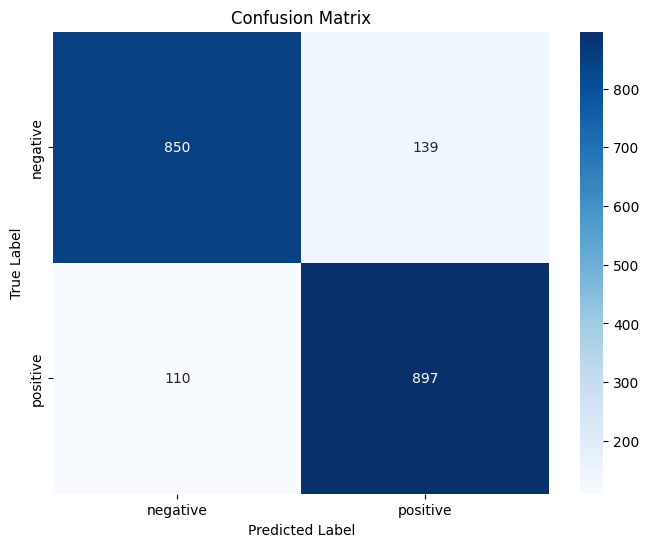

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels
class_labels = logistic_model.classes_ # Assumes 'positive' and 'negative' or similar

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Precision, Recall, and F1-Score

These metrics are particularly useful when dealing with imbalanced datasets, but also provide a more granular view of performance even with balanced classes.

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision for 'positive' class (assuming it's the positive class)
precision_positive = precision_score(y_test, y_pred, pos_label='positive')
print(f"Precision (Positive): {precision_positive:.4f}")

# Calculate Recall for 'positive' class
recall_positive = recall_score(y_test, y_pred, pos_label='positive')
print(f"Recall (Positive): {recall_positive:.4f}")

# Calculate F1-Score for 'positive' class
f1_positive = f1_score(y_test, y_pred, pos_label='positive')
print(f"F1-Score (Positive): {f1_positive:.4f}")

print("\n---")

# Calculate Precision for 'negative' class
precision_negative = precision_score(y_test, y_pred, pos_label='negative')
print(f"Precision (Negative): {precision_negative:.4f}")

# Calculate Recall for 'negative' class
recall_negative = recall_score(y_test, y_pred, pos_label='negative')
print(f"Recall (Negative): {recall_negative:.4f}")

# Calculate F1-Score for 'negative' class
f1_negative = f1_score(y_test, y_pred, pos_label='negative')
print(f"F1-Score (Negative): {f1_negative:.4f}")

Precision (Positive): 0.8658
Recall (Positive): 0.8908
F1-Score (Positive): 0.8781

---
Precision (Negative): 0.8854
Recall (Negative): 0.8595
F1-Score (Negative): 0.8722


### Generate `requirements.txt`

To ensure reproducibility of your project, it's good practice to list all the dependencies in a `requirements.txt` file. You can generate this file by running the following command:

In [21]:
!pip freeze > requirements.txt
print("Generated requirements.txt:")
!cat requirements.txt

Generated requirements.txt:
absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.0
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.6.1.17.39.59
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.41.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.4.1
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue=

9th June


In [ ]:
s = "python p"

In [ ]:
char_frequency = {}
for char in s:
    if char in char_frequency:
        char_frequency[char] += 1
    else:
        char_frequency[char] = 1

print("Character frequency:", char_frequency)

Character frequency: {'p': 2, 'y': 1, 't': 1, 'h': 1, 'o': 1, 'n': 1, ' ': 1}


In [ ]:
new_char_frequency = {}
for char in s:
    if char in new_char_frequency:
        new_char_frequency[char] += 1
    else:
        new_char_frequency[char] = 1

print("New character frequency:", new_char_frequency)

New character frequency: {'p': 2, 'y': 1, 't': 1, 'h': 1, 'o': 1, 'n': 1, ' ': 1}


In [ ]:
text = 'Artificial intelligence (AI) is a branch of computer science focused on building systems capable of performing tasks that typically require human intellect, such as learning, reasoning, perception, and decision-making. Unlike traditional software that follows rigid rules, AI learns from vast amounts of data to recognize patterns and adapt over time.'

In [ ]:
import re

# Clean the text (remove punctuation and convert to lowercase)
cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

# Tokenize the cleaned text into words
words = cleaned_text.split()

# Calculate word frequency using a for loop
word_frequency = {}
for word in words:
    if word in word_frequency:
        word_frequency[word] += 1
    else:
        word_frequency[word] = 1

print("Word frequency:", word_frequency)

Word frequency: {'artificial': 1, 'intelligence': 1, 'ai': 2, 'is': 1, 'a': 1, 'branch': 1, 'of': 3, 'computer': 1, 'science': 1, 'focused': 1, 'on': 1, 'building': 1, 'systems': 1, 'capable': 1, 'performing': 1, 'tasks': 1, 'that': 2, 'typically': 1, 'require': 1, 'human': 1, 'intellect': 1, 'such': 1, 'as': 1, 'learning': 1, 'reasoning': 1, 'perception': 1, 'and': 2, 'decisionmaking': 1, 'unlike': 1, 'traditional': 1, 'software': 1, 'follows': 1, 'rigid': 1, 'rules': 1, 'learns': 1, 'from': 1, 'vast': 1, 'amounts': 1, 'data': 1, 'to': 1, 'recognize': 1, 'patterns': 1, 'adapt': 1, 'over': 1, 'time': 1}


## COMPUTER VISION


In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import numpy as np

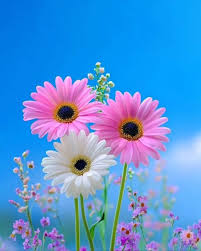

In [ ]:
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/images flower.jpg')
cv2_imshow(img)

In [ ]:
from IPython.display import display, Javascript
display(Javascript('''
  var video = document.createElement('video');
  video.style.display = 'block';
  navigator.mediaDevices.getUserMedia({video: true}).then(stream => {
    video.srcObject = stream;
    video.play();
    document.body.appendChild(video);
    google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
  });
'''))

<IPython.core.display.Javascript object>